# Visual Analytics - Melanoma Classification

## Imports

In [44]:
# python modules
import numpy as np
import pandas as pd
import seaborn as snb
import matplotlib as mlt

In [45]:
# custom modules
from utils.get_data import get_data
from utils.plots.show_image import show_single_image, show_images

## Globals

In [33]:
IMG_DIR = "/mnt/san256/siic-224/"

In [7]:
# automatic reload magic
%load_ext autoreload
%autoreload 2

Get the csv files

In [71]:
cancer_index = pd.read_csv("data/Index-Hautkrebsanfaelligkeit.csv", sep=";")
conver_index_so = pd.read_csv("data/Sozio-oekonomischer-Hautkrebsindex.csv", sep=";")

In [41]:
test_df = get_data("data/test.csv", "test", IMG_DIR)
train_df = get_data("data/train.csv", "train", IMG_DIR)

valid rows 10982
valid rows 33126


In [69]:
cancer_index.head()

,Land,Region,Hautkrebs-Inzidenz,Melanom Erkrankungen pro Jahr,UV-Intensität (ø),Hattyp (ø)
0,Neuseeland,Australia,10,2473,"6,88","4,75"
1,Australien,Australia,"9,67",12265,"7,35","5,75"
2,Schweiz,Europe,"5,89",2484,"2,8","7,75"
3,Schweden,Europe,"5,79",2911,"1,28","9,75"
4,Norwegen,Europe,"5,71",1506,1,10


In [79]:
conver_index_so = conver_index_so[['Land', 'Sterblichkeitsrate', 'Ungleichheit der Lebenserwartung', 'Nationale Gesundheitsausgaben', 'Gesamtwertung']]
conver_index_so.head()

,Land,Sterblichkeitsrate,Ungleichheit der Lebenserwartung,Nationale Gesundheitsausgaben,Gesamtwertung
0,Schweden,17.00%,"3,11","4,20",8.4
1,Schweiz,15.00%,"3,92","2,81",8.4
2,Italien,14.00%,"3,35","6,32",8.9
3,Dänemark,14.00%,"3,96","4,28",9.0
4,Deutschland,16.00%,"3,68","4,93",9.2


### Erklärung der Daten

- Hautkrebs-Inzidenz: Anzahl neuer Hautkrebsfälle pro Jahr, gemessen an der Bevölkerung (skaliert von 1-10).
- Durchschnittliche UV-Intensität: Der Wert gibt an wie stark die UV-Strahlung im Jahresdurchschnitt in den einzelnen Ländern ist (skaliert von 1-10, größer = stärkere Strahlung).
- Durchschnittlicher Hauttyp: Basierend auf der Fitzpatrick-Skala, gibt dieser Wert an, wie stark Pigmentiert die Bevölkerung im Durchschnitt ist (skaliert von 1-10, größer = hellere Haut und somit anfälliger für Hautkrebs).
- Sozioökonomischer Index: In diesem Teil gilt für alle Zahlen, dass eine kleinere Zahl einen höheren Behandlungsstandard repräsentiert (kleiner = besser).
- Nationale Gesundheitsausgaben: Umso kleiner die Zahl, umso mehr geben die Länder für das Gesundheitssystem aus (skaliert von 1-10, kleiner = mehr).

Source: https://derma.plus/hautkrebs-index-2018 & https://derma.plus/globaler-hautkrebs-index

In [42]:
train_df.head()

,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target,image_path
0,ISIC_2637011,IP_7279968,male,45.0,head/neck,unknown,benign,0,/mnt/san256/siic-224/train/ISIC_2637011.png
1,ISIC_0015719,IP_3075186,female,45.0,upper extremity,unknown,benign,0,/mnt/san256/siic-224/train/ISIC_0015719.png
2,ISIC_0052212,IP_2842074,female,50.0,lower extremity,nevus,benign,0,/mnt/san256/siic-224/train/ISIC_0052212.png
3,ISIC_0068279,IP_6890425,female,45.0,head/neck,unknown,benign,0,/mnt/san256/siic-224/train/ISIC_0068279.png
4,ISIC_0074268,IP_8723313,female,55.0,upper extremity,unknown,benign,0,/mnt/san256/siic-224/train/ISIC_0074268.png


In [52]:
test_df.head()

,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,image_path
0,ISIC_0052060,IP_3579794,male,70.0,NaN,/mnt/san256/siic-224/test/ISIC_0052060.png
1,ISIC_0052349,IP_7782715,male,40.0,lower extremity,/mnt/san256/siic-224/test/ISIC_0052349.png
2,ISIC_0058510,IP_7960270,female,55.0,torso,/mnt/san256/siic-224/test/ISIC_0058510.png
3,ISIC_0073313,IP_6375035,female,50.0,torso,/mnt/san256/siic-224/test/ISIC_0073313.png
4,ISIC_0073502,IP_0589375,female,45.0,lower extremity,/mnt/san256/siic-224/test/ISIC_0073502.png


Display 9 random images from the train df

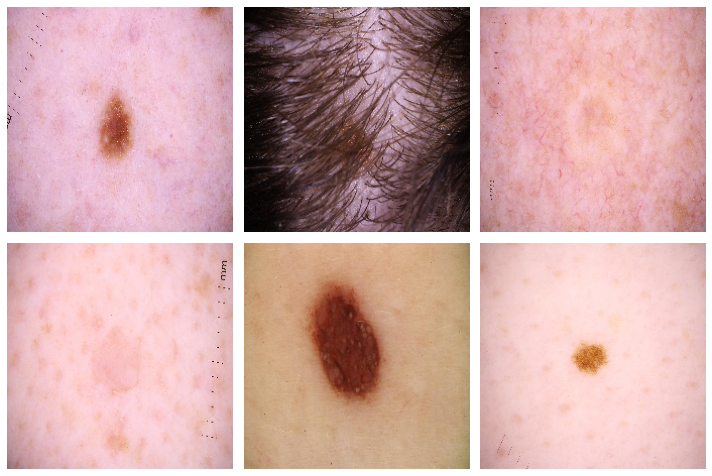

In [65]:
imgs = list(train_df.sample(9).image_path)
show_images(imgs, 3, 2)

## Wie sieht die weltweite Verteilung der Hautkrebserkrankungen aus?

- Daten ziehen: https://derma.plus/hautkrebs-index-2018/
- Quellen + Bilder: https://derma.plus/globaler-hautkrebs-index/

- Alle Fragen notieren (auch zusätzliche Fragen die ich mit den Daten beantworten kann / will)